**Importing and Formating the Data**

In [16]:
import pandas as pd

df = pd.read_csv('Formatted_DataCo_Dataset_Clean.csv')

df = df[['order_date_dateorders', 'sales']]

df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'], errors='coerce')

df = df.dropna(subset=['order_date_dateorders'])

df = df.sort_values('order_date_dateorders')


**Aggregating the Monthly Sales**

In [17]:
monthly_sales = df.resample('M', on='order_date_dateorders')['sales'].sum().reset_index()
monthly_sales.head()


/tmp/ipython-input-1912286865.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='order_date_dateorders')['sales'].sum().reset_index()


,order_date_dateorders,sales
0,2015-01-31,880316.386542
1,2015-02-28,744016.994172
2,2015-03-31,870281.176509
3,2015-04-30,747284.836733
4,2015-05-31,803477.377700


**Current Sale visualised**

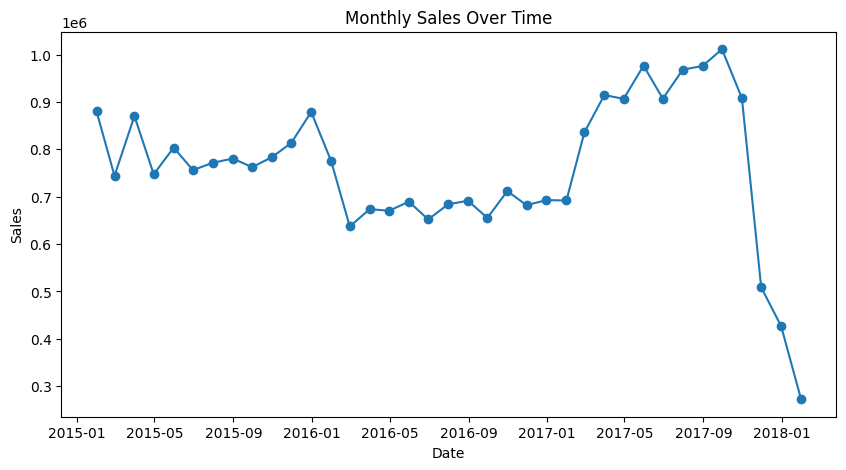

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['order_date_dateorders'], monthly_sales['sales'], marker='o')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


**This Year's Sales Total**

In [28]:
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])
sales_2017 = df[df['order_date_dateorders'].dt.year == 2017]['sales'].sum()
print("Total sales for 2017:", round(sales_2017,2))


Total sales for 2017: 10030873.4


In [19]:
!pip install prophet

**Formatting data for Prophet**

In [20]:
from prophet import Prophet

df_prophet = monthly_sales.rename(columns={
    'order_date_dateorders': 'ds',
    'sales': 'y'
})

In [21]:
model = Prophet()
model.fit(df_prophet)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmphvxe7nh2/tqrlv5sn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmphvxe7nh2/c5qvvjgh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=98772', 'data', 'file=/tmp/tmphvxe7nh2/tqrlv5sn.json', 'init=/tmp/tmphvxe7nh2/c5qvvjgh.json', 'output', 'file=/tmp/tmphvxe7nh2/prophet_modelf7vujez5/prophet_model-20251027125931.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
12:59:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:59:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


**Forecasting for next 12 months**

In [22]:
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
37,2018-02-28,691759.409775,520007.581271,875221.682628
38,2018-03-31,803590.588758,634599.479386,971079.323416
39,2018-04-30,741468.015615,561355.924658,912876.850783
40,2018-05-31,805327.115870,637289.613232,977789.529754
41,2018-06-30,758775.057913,589858.919743,926640.368905
42,2018-07-31,790614.756522,605986.756023,961602.730214
43,2018-08-31,795013.165980,619479.987088,968660.192708
44,2018-09-30,781367.947992,615882.451803,953515.765320
45,2018-10-31,761102.751221,587990.777233,948599.808219
46,2018-11-30,650499.940440,481391.964883,828839.708290


**Next years Sales visualised**

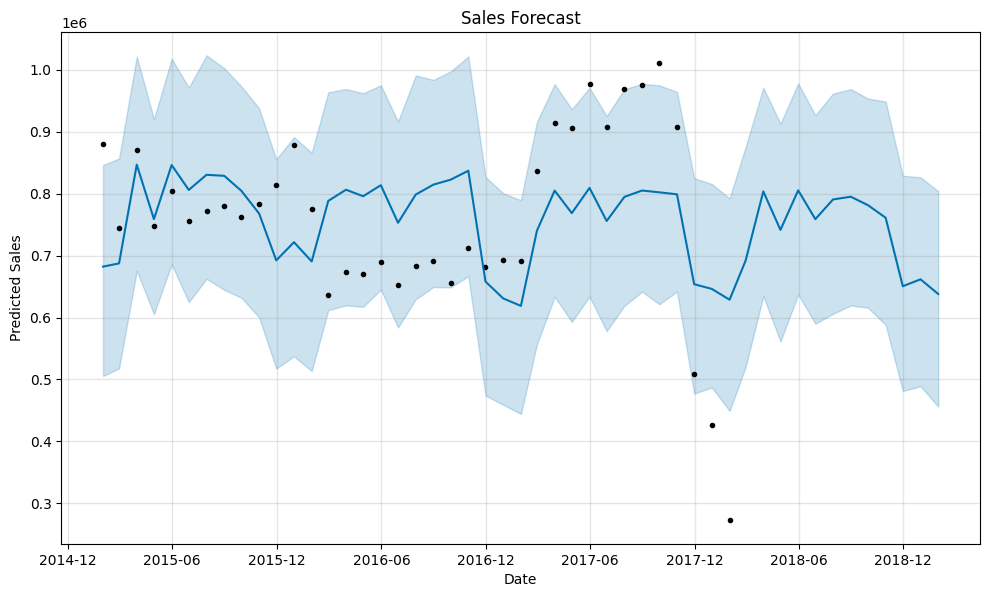

In [23]:
model.plot(forecast)
plt.title('Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')
plt.show()


In [29]:
next_month = forecast.tail(12).iloc[0]['yhat']
next_6_months = forecast.tail(6)['yhat'].sum()
next_year_total = forecast.tail(12)['yhat'].sum()

print("Next Month Forecast:", round(next_month, 2))
print("Next 6 Months Total:", round(next_6_months, 2))
print("Next 1 Year Total:", round(next_year_total, 2))
print("This Year's Total:", round(sales_2017,2))


Next Month Forecast: 691759.41
Next 6 Months Total: 4287639.38
Next 1 Year Total: 8879174.32
This Year's Total: 10030873.4


**Comparing current year's Sales and Predicted Sales**

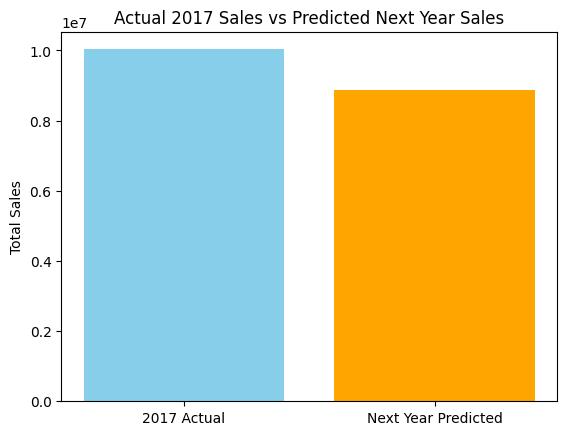

In [30]:
import matplotlib.pyplot as plt

plt.bar(['2017 Actual', 'Next Year Predicted'], [sales_2017, next_year_total], color=['skyblue', 'orange'])
plt.title('Actual 2017 Sales vs Predicted Next Year Sales')
plt.ylabel('Total Sales')
plt.show()